### Gather Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPolygon
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl
import pickle
%matplotlib inline
# # 20744099999 - Малые Кармакулы, 20891099999 - Хатанга

# df = pd.read_parquet('world_stations_full.parquet')
df = pd.read_parquet('world_stations_25_days_6_months.parquet')
# dirty shape (165776602, 13)
# without nans (164739214, 13)
# without poor stations (164392026, 13)
# without poor coords (164375346, 13)
# CLEAN (138636132, 13)
df

,DATE,STATION,NAME,MXWDSP,WDSP,TEMP,STP,SLP,PRCP,DEWP,LATITUDE,LONGITUDE,ELEVATION
0,1949-02-27,30846099999,"ULETY, RS",4.578516,1.954872,-10.388889,NaN,1025.5,0.0508,NaN,51.350,112.466667,743.0
1,1949-02-28,30846099999,"ULETY, RS",0.977436,0.771660,-8.611111,NaN,1024.0,0.0508,NaN,51.350,112.466667,743.0
2,1949-03-02,30846099999,"ULETY, RS",2.623644,1.234656,-9.333333,NaN,1017.5,0.0000,NaN,51.350,112.466667,743.0
3,1949-03-03,30846099999,"ULETY, RS",4.578516,3.240972,-12.055556,NaN,1030.9,0.0000,NaN,51.350,112.466667,743.0
4,1949-03-04,30846099999,"ULETY, RS",4.578516,2.726532,-8.722222,NaN,1027.7,0.0000,NaN,51.350,112.466667,743.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
138636127,1963-01-23,56741099999,"LIU KU, CH",4.115520,1.646208,10.444444,921.7,NaN,0.0000,-1.388889,25.783,98.850000,2377.0
138636128,1963-01-24,56741099999,"LIU KU, CH",5.092956,2.469312,10.777778,923.2,NaN,0.0000,-0.666667,25.783,98.850000,2377.0
138636129,1963-01-25,56741099999,"LIU KU, CH",3.086640,1.697652,9.833333,923.8,NaN,0.0000,0.888889,25.783,98.850000,2377.0
138636130,1963-01-26,56741099999,"LIU KU, CH",5.092956,1.749096,10.388889,922.1,NaN,0.0000,-0.555556,25.783,98.850000,2377.0


In [3]:
def fahr_to_celsius(temp_fahr):
    """Convert Fahrenheit to Celsius.
    
    Return Celsius conversion of input"""
    return (temp_fahr - 32) * 5 / 9

def knots_to_ms(windspeed):
    """Convert Knots to m/s.
    
    Return m/s conversion of input"""
    return windspeed * 0.51444

def preprocess_csv(title):
    """Preprocess a .csv file.
    
    Return preprocessed .csv of a station"""
    
    df = pd.read_csv(title)

    df = df[['DATE', 'STATION', 'NAME', 'GUST', 'WDSP', 'TEMP', 'STP', 'SLP', 'PRCP', 'DEWP', 'MXSPD', 'LATITUDE', 'LONGITUDE', 'ELEVATION']]

    df = df.replace([99.99, 999.9, 9999.9], np.nan) # add [-999., -999.9] to the list

    df['DATE'] = pd.to_datetime(df['DATE'])

    # Speed
    df["MAXWDSP"] = df[["GUST", "MXSPD"]].max(axis=1)
    df.insert(3, 'MXWDSP', df.pop("MAXWDSP"))
    df.drop('GUST', axis=1, inplace=True)
    df.drop('MXSPD', axis=1, inplace=True)

    # Temperature
    df['TEMP'] = df['TEMP'].apply(fahr_to_celsius)
    df['DEWP'] = df['DEWP'].apply(fahr_to_celsius)

    df['MXWDSP'] = df['MXWDSP'].apply(knots_to_ms)
    df['WDSP'] = df['WDSP'].apply(knots_to_ms)

    df['STP'] = df['STP'].apply(lambda x: (x + 1000) if x < 100 else x)
    # df['SLP'] = df['SLP'].apply(lambda x: (x + 1000) if x < 100 else x)

    df['PRCP'] = df['PRCP'] * 2.54

    return df
preprocess_csv("2020/20891099999.csv")

,DATE,STATION,NAME,MXWDSP,WDSP,TEMP,STP,SLP,PRCP,DEWP,LATITUDE,LONGITUDE,ELEVATION
0,2020-01-01,20891099999,"HATANGA, RS",6.996384,5.607396,-16.444444,997.1,1001.5,0.0508,-20.055556,71.983333,102.466667,33.0
1,2020-01-02,20891099999,"HATANGA, RS",4.990068,2.726532,-23.388889,998.7,1003.3,0.0000,-25.833333,71.983333,102.466667,33.0
2,2020-01-03,20891099999,"HATANGA, RS",2.983752,1.851984,-22.444444,1000.2,1004.8,0.1524,-24.111111,71.983333,102.466667,33.0
3,2020-01-04,20891099999,"HATANGA, RS",4.012632,3.138084,-23.777778,998.2,1002.7,0.3048,-26.000000,71.983333,102.466667,33.0
4,2020-01-05,20891099999,"HATANGA, RS",4.012632,3.395304,-28.388889,994.7,999.2,0.0000,-30.833333,71.983333,102.466667,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,2020-12-27,20891099999,"HATANGA, RS",6.018948,4.578516,-25.222222,1044.5,1049.2,0.0508,-27.055556,71.983333,102.466667,33.0
352,2020-12-28,20891099999,"HATANGA, RS",9.002700,7.973820,-27.444444,1047.3,1052.1,0.0508,-29.888889,71.983333,102.466667,33.0
353,2020-12-29,20891099999,"HATANGA, RS",7.973820,6.481944,-33.000000,1049.4,1054.4,0.0508,-35.444444,71.983333,102.466667,33.0
354,2020-12-30,20891099999,"HATANGA, RS",4.012632,2.623644,-36.333333,1047.0,1052.0,0.0000,-38.888889,71.983333,102.466667,33.0


In [25]:
# Script to preprocess all folders and gather them into one Dictionary
parent = os.getcwd()
all_stations = {}
all_years = sorted(next(os.walk('.'))[1])[86:] # Should start from 1929
for year in all_years:
    print(year)
    os.chdir(year) # go to a folder
    files = os.listdir() # list all files
    for file in files:
        if file in all_stations:
            all_stations[file] = pd.concat([all_stations[file], preprocess_csv(file)]) # merge with previous years
        else:
            all_stations[file] = preprocess_csv(file) # create new key-value pair
    os.chdir(parent) # get back to the parent directory

df = pd.concat(all_stations.values(), ignore_index=True)
df
# till 2012 (included) - 110 mins
# 2013-2023 - 50 mins

2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [ ]:
## Code to dump and load pickle files
# import pickle
# with open('1929-2012.pkl', 'rb') as fp:
#     person = pickle.load(fp)
# with open('1929-2012.pkl', 'wb') as fp:
#     pickle.dump(all_stations, fp)

In [29]:
## This code needs to unite 1929-2012.pkl with 2013-2023.pkl
# pp = set(till_1999.keys())
# aa = set(till_2013.keys())
# all_keys = pp.union(aa)
# final = {}
# for key in all_keys:
#     if (key in pp) and (key in aa):
#         final[key] = pd.concat([till_1999[key], till_2013[key]])
#     else:
#         try:
#             final[key] = till_1999[key]
#         except:
#             final[key] = till_2013[key]

In [33]:
## This code is for the final merger of Dictionary to DataFrame 
# df = pd.concat(finall.values(), ignore_index=True)
# df['STATION'] = df['STATION'].astype('str')
# df.to_parquet('world_stations_full.parquet')

In [ ]:
## This code to preprocess 'world_stations_without_preprocessing.parquet'
# df = df.replace([-999., -999.9], np.nan)
# df = df.dropna(subset = ['ELEVATION', 'LONGITUDE']) # drop nans for elevation and longitude
# from collections import Counter
# cnt = Counter(np.array(df.STATION)) # drop stations with poor observations
# less_365 = [k for k, v in cnt.items() if v < 365]
# df = df[~(df['STATION'].isin(less_365))]
# wrong_coords = ['PLATFORM NUMBER 62117, US', 'SEDCO 706, CA', 'BOGUS ROMANIAN, RO', 'WXPOD8270', 'ENVIRONM BUOY 62109, US', 'AFWA ASSIGNED']
# df = df[~(df['NAME'].isin(wrong_coords))] # drop stations with poor coords
# df.reset_index(inplace=True, drop=True) # reset indices

### Make a table and a map of stations

Индекс ВМО,Наименование станции,Широта,Долгота,Высота метеопл.,Начало наблюдений,

In [26]:
dff = df.drop_duplicates(subset = ["STATION"])[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION']]
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# world = world[(world.pop_est>0) & (world.name!="Antarctica")] # Remove Antarctica

dff["Coordinates"] = list(zip(dff['LONGITUDE'], dff['LATITUDE']))
dff["Coordinates"] = dff["Coordinates"].apply(Point)
gdf = gpd.GeoDataFrame(dff, geometry="Coordinates")
dff

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION
0,30846099999,"ULETY, RS",51.350000,112.466667,743.00
21770,72340953869,"BLYTHEVILLE MUNICIPAL AIRPORT, AR US",35.940280,-89.830830,77.70
28030,11356099999,"BAD AUSSEE, AU",47.616667,13.750000,747.00
37788,99999926540,"OLD MAN, AK US",67.450000,-150.583330,11.00
38154,8223099999,"CUATRO VIENTOS, SP",40.370678,-3.785144,690.98
...,...,...,...,...,...
165750466,74516099999,"FAIRFIELD TRAVIS AF, CA US",38.267000,-121.950000,22.00
165752291,24668099999,"VERHOJANSK PEREVOZ, RS",63.316667,132.016667,90.92
165764333,15299099999,"RUCAR, RO",45.400000,25.167000,581.00
165768096,70206026632,"NORTHEAST CAPE, AK US",63.316670,-168.966670,9.10


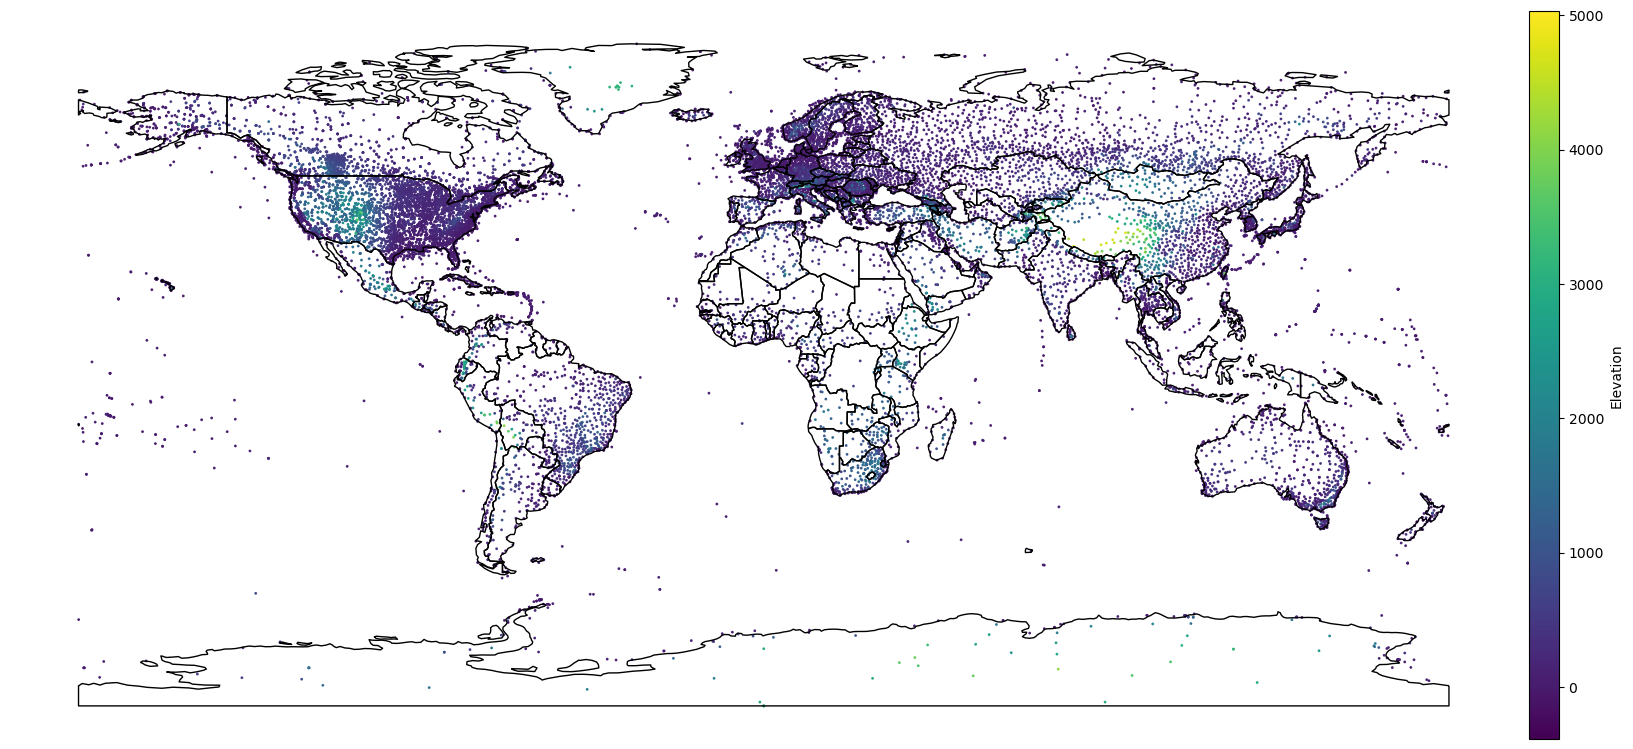

In [66]:
fig, gax = plt.subplots(figsize=(20, 20))
# heatmap.plot()
divider = make_axes_locatable(gax)
cax = divider.append_axes("right", size="2%", pad=0.1)
gdf.plot(ax=gax, marker='o', markersize=1, alpha = 0.95, column='ELEVATION', legend=True, cax=cax,
         legend_kwds={'label': "Elevation",}) # 'orientation': "vertical"
world.boundary.plot(ax=gax, edgecolor="black", lw=1, alpha = 1)

gax.set_axis_off()
# plt.xlim(18, 190)
# plt.ylim(40,)

Remove:

- 'PLATFORM NUMBER 62117, US' because coords 57.92 0.0 is not USA, poor data
- 'SEDCO 706, CA' no data, 1 year 
- 'BOGUS ROMANIAN, RO' (6700) term "bogus" indicates that the station name, etc are not available
- 'WXPOD8270' poor data
- 'ENVIRONM BUOY 62109, US' poor data
- 'AFWA ASSIGNED'(4000) - two secret Air Force Weather Agency stations 

Question
- 'UNIVERSITY WI ID 8987 CLEAN AIR, AY' (3700 samples), 'KOHNEN EP9, AY' (4800), 'AMUNDSEN SCOTT, AY' (18500) - Antarctica may confuse model, probably should **remove AY?**

In [2]:
dff = df[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE']]
dff

,STATION,NAME,LATITUDE,LONGITUDE
0,30846099999,"ULETY, RS",51.350,112.466667
1,30846099999,"ULETY, RS",51.350,112.466667
2,30846099999,"ULETY, RS",51.350,112.466667
3,30846099999,"ULETY, RS",51.350,112.466667
4,30846099999,"ULETY, RS",51.350,112.466667
...,...,...,...,...
165776597,56741099999,"LIU KU, CH",25.783,98.850000
165776598,56741099999,"LIU KU, CH",25.783,98.850000
165776599,56741099999,"LIU KU, CH",25.783,98.850000
165776600,56741099999,"LIU KU, CH",25.783,98.850000


In [2]:
# Script to gather all stations with their coordinates
parent = os.getcwd()
all_stations = {}
all_years = sorted(next(os.walk('.'))[1])[1:] # Should start from 1929
for year in all_years:
    print(year)
    os.chdir(year) # go to a folder
    files = os.listdir() # list all files
    for file in files:
        if file not in all_stations:
            all_stations[file] = pd.read_csv(file)[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE']].iloc[0]
            ## Code below is used to find end date of measurements. The condition "if file in all_stations:" should be returned.
            # df = pd.read_csv(file)
            # line = df[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'DATE']].iloc[0] 
            # line['END'] = df['DATE'].iloc[-1]
            # all_stations[file] = line # create new key-value pair
            
    os.chdir(parent) # get back to the parent directory
final = pd.DataFrame(all_stations.values())
final['STATION'] = final['STATION'].astype('str')
final

1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE
0,3497099999,"GORLESTON, UK",52.583000,1.717000,3.00,1929-08-01
0,3601099999,"ST. ANNES HEAD, UK",51.683000,-5.167000,43.00,1929-10-01
0,3980099999,"MALIN HEAD, EI",55.366667,-7.333333,25.00,1929-10-01
0,3075099999,"WICK, UK",58.458889,-3.093056,38.40,1929-10-01
0,3864099999,NaN,NaN,NaN,NaN,1929-10-01
...,...,...,...,...,...,...
0,48967099999,"KAMPONG CHHNANG, CB",12.255236,104.563875,17.06,2022-11-27
0,36944099999,"KYZYL SUU, KG",42.350000,78.350000,1769.00,2023-01-12
0,64972099999,"EBOLOWA, CM",2.900000,11.166667,628.00,2023-01-20
0,64285099999,"KALEMIE, CG",-5.883333,29.183333,790.00,2023-01-27


In [75]:
# Second script to preprocess all folders and gather them into one Dictionary
parent = os.getcwd()
all_stations = {}
all_years = sorted(next(os.walk('.'))[1])[1:] # Should start from 1929
for year in all_years:
    print(year)
    os.chdir(year) # go to a folder
    files = os.listdir() # list all files
    for file in files:
        all_stations[file] = pd.read_csv(file)[['STATION', 'NAME', 'LATITUDE', 'LONGITUDE', 'ELEVATION']].iloc[-1]
        
    os.chdir(parent) # get back to the parent directory

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023


In [21]:
print('NaN in STATION:', final[final['STATION'].isna()].shape[0])
print('NaN in NAME:', final[final['NAME'].isna()].shape[0])
print('NaN in LONGITUDE:', final[final['LONGITUDE'].isna()].shape[0])
print('NaN in LATITUDE:', final[final['LATITUDE'].isna()].shape[0])
print('NaN in ELEVATION:', final[final['ELEVATION'].isna()].shape[0])
# print('Two stations (72222013899, 99999954783) got values later, because LATITUDE from nan_latitude.csv:', nan_latitude.shape[0])

NaN in STATION: 0
NaN in NAME: 1400
NaN in LONGITUDE: 1664
NaN in LATITUDE: 1663
NaN in ELEVATION: 1715


### Check for continuity

In [2]:
dff = df.copy()
df = df[['DATE', 'STATION']]
df

,DATE,STATION
0,1948-01-03,30846099999
1,1948-01-04,30846099999
2,1948-01-05,30846099999
3,1948-01-09,30846099999
4,1948-01-11,30846099999
...,...,...
164375341,1998-04-01,56741099999
164375342,1998-04-13,56741099999
164375343,1998-04-17,56741099999
164375344,1998-08-01,56741099999


In [3]:
def preprocess_grouped(grouped):
    cont = 0
    previous_was_okay = 0
    list_of_dates = []
    start_date = grouped.index[0]
    for (date, i) in zip(grouped.index, grouped.STATION):
        if i >= 25:                  # try >=20 and ==28     Days in a 4-week period, should be 28
            cont += 1
            if cont >= 6:            # try >=3 and >=12      Continuous periods in a row
                end_date = date
                previous_was_okay = 1                      # Flag that says that previous 4-week period was continuous
        
        else: 
            cont = 0
            if previous_was_okay:
                list_of_dates.append([start_date, end_date])
                previous_was_okay = 0
            start_date = date
    if previous_was_okay:
        list_of_dates.append([start_date, end_date])
        previous_was_okay = 0     
    return list_of_dates

In [5]:
df = df[['DATE', 'STATION']]
gg = df.groupby('STATION')
indices_final = []
dic = {}
for one_station in gg:
    print(one_station[0])
    grouped = one_station[1].groupby([pd.Grouper(key='DATE', freq='4W')]).count()
    cont_periods = preprocess_grouped(grouped)
    if cont_periods:

        mask = one_station[1].DATE.between(cont_periods[0][0], cont_periods[0][1])
        for i in cont_periods:
            mask += one_station[1].DATE.between(i[0], i[1])
        indices_final.extend(one_station[1].index[mask].tolist())

result = sorted(indices_final)
# 4:20

10000199999
10001099999
10002099999
10003199999
10004099999
10005099999
10006099999
10007099999
1001099999
1001499999
10015099999
1001599999
1001699999
1001799999
10018099999
10019599999
10020099999
1002099999
10022099999
10026099999
10028099999
1003099999
10033099999
10034099999
10035099999
10037099999
10038099999
10042099999
10044099999
10045099999
10046099999
10046599999
10048099999
1005099999
10055099999
1006099999
10063099999
10067099999
1007099999
1008099999
1009099999
10091099999
10093099999
10097099999
1010099999
1011099999
10113099999
10120099999
10122099999
10123099999
10124099999
10126099999
10127099999
10128099999
10129099999
10130099999
10131099999
10136099999
10139099999
1014099999
10142099999
10143099999
10146099999
10147099999
10148099999
10149099999
10150099999
1015099999
10151099999
10152099999
10156099999
1016099999
10161099999
10162099999
10162499999
10163099999
10168099999
10170099999
1017099999
10172099999
10177099999
10178099999
10180099999
10181099999
1018409999

In [7]:
# with open("indices_final", "wb") as fp:   #Pickling
#   pickle.dump(result, fp)
# with open("indices_final", "rb") as fp:   # Unpickling
#     b = pickle.load(fp)

### Examples of cleaning from discrete stations

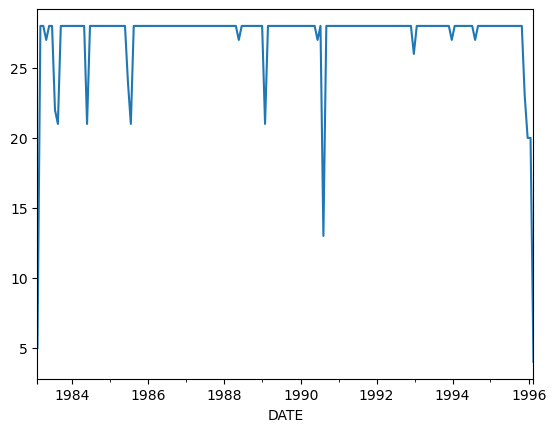

In [39]:
old_count_stations('2252099999')

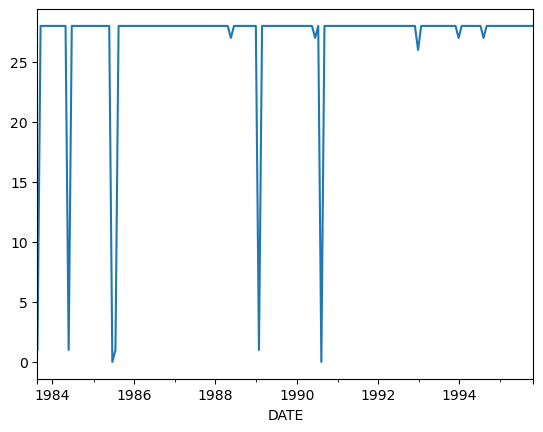

In [40]:
count_stations('2252099999')

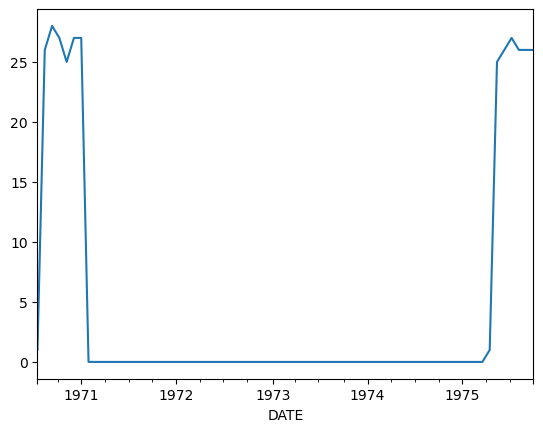

In [36]:
count_stations('24095099999')

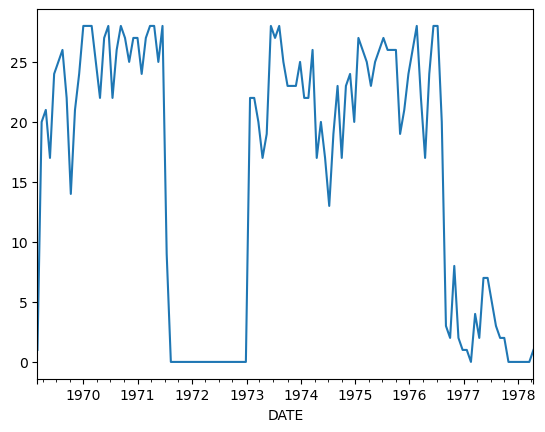

In [ ]:
old_count_stations('24095099999')

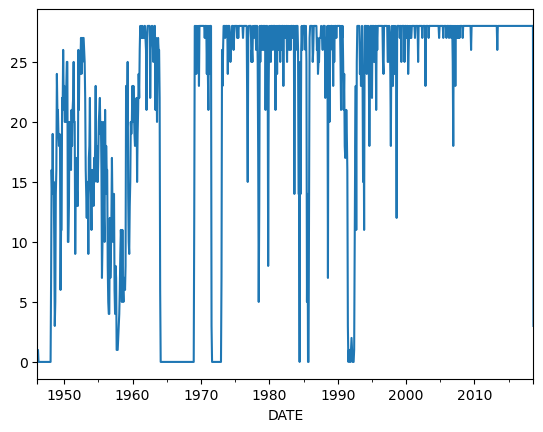

In [15]:
count_stations('29822099999')

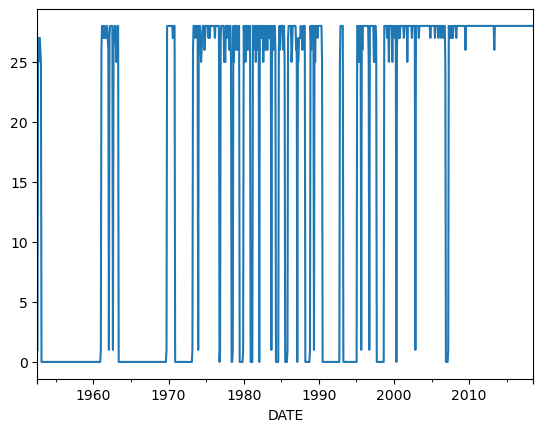

In [ ]:
count_stations('29822099999')

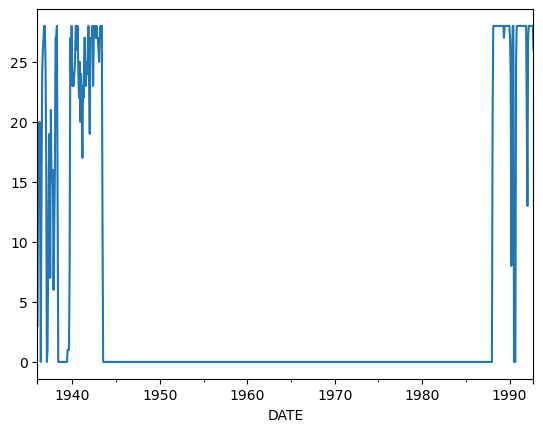

In [10]:
count_stations('10001099999')

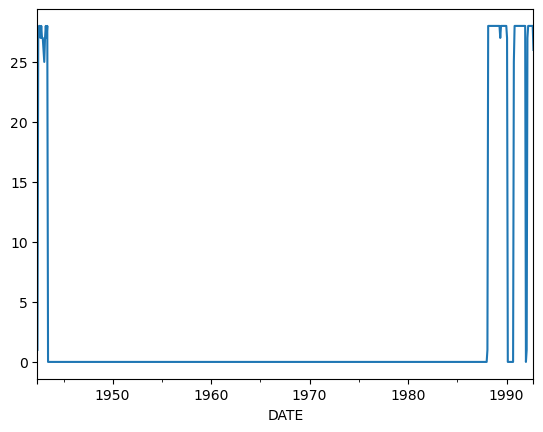

In [ ]:
count_stations('10001099999')

In [ ]:
# To check the validity of mask 
# ddd = dfff.index[dfff.DATE.between(datt[0][0], datt[0][1]) + dfff.DATE.between(datt[1][0], datt[1][1]) + dfff.DATE.between(datt[2][0], datt[2][1]) + dfff.DATE.between(datt[3][0], datt[3][1]) + dfff.DATE.between(datt[4][0], datt[4][1])].tolist()
# len(ddd)

In [37]:
def count_stations(station):
    dd = dff[dff['STATION'] == station]
    grouped = dd.groupby([pd.Grouper(key='DATE', freq='4W')]).count()
    grouped.STATION.plot()

def old_count_stations(station):
    dd = df[df['STATION'] == station]
    grouped = dd.groupby([pd.Grouper(key='DATE', freq='4W')]).count()
    grouped.STATION.plot()

In [10]:
dff = df.loc[df['STATION'] == '72340953869']
grouped = dff.groupby([pd.Grouper(key='DATE', freq='4W')]).count()
grouped

,STATION
DATE,
2006-01-01,1
2006-01-29,28
2006-02-26,28
2006-03-26,28
2006-04-23,28
...,...
2022-12-11,28
2023-01-08,28
2023-02-05,28


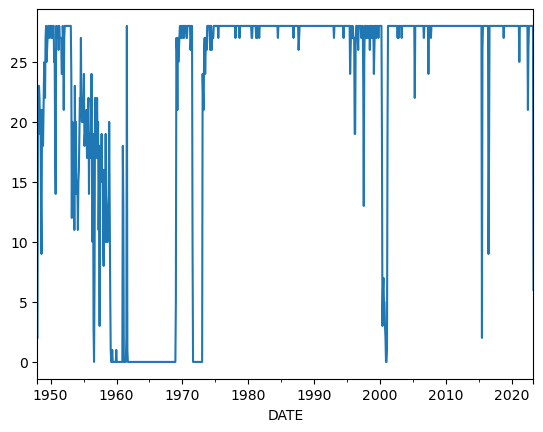

In [28]:
count_stations('30846099999')

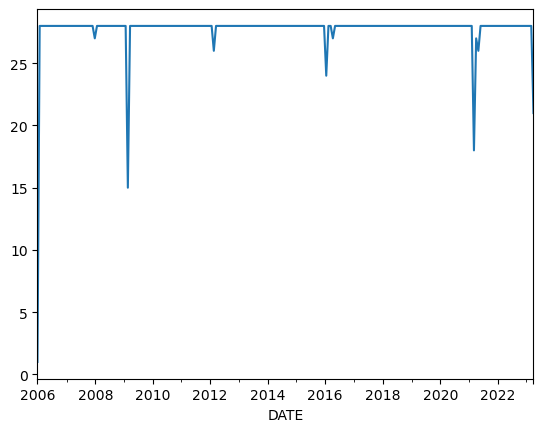

In [29]:
count_stations('72340953869')

In [64]:
list_of_dates

[[Timestamp('2006-01-01 00:00:00', freq='4W-SUN'),
  Timestamp('2009-01-25 00:00:00', freq='4W-SUN')],
 [Timestamp('2009-02-22 00:00:00', freq='4W-SUN'),
  Timestamp('2015-12-20 00:00:00', freq='4W-SUN')],
 [Timestamp('2016-01-17 00:00:00', freq='4W-SUN'),
  Timestamp('2021-02-07 00:00:00', freq='4W-SUN')],
 [Timestamp('2021-03-07 00:00:00', freq='4W-SUN'),
  Timestamp('2023-03-05 00:00:00', freq='4W-SUN')]]

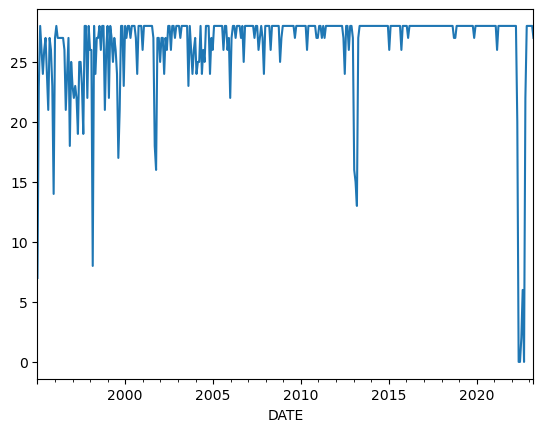

In [30]:
count_stations('11356099999')

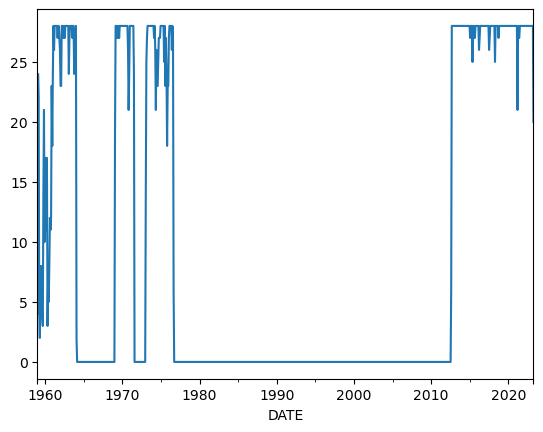

In [31]:
count_stations('25469099999')

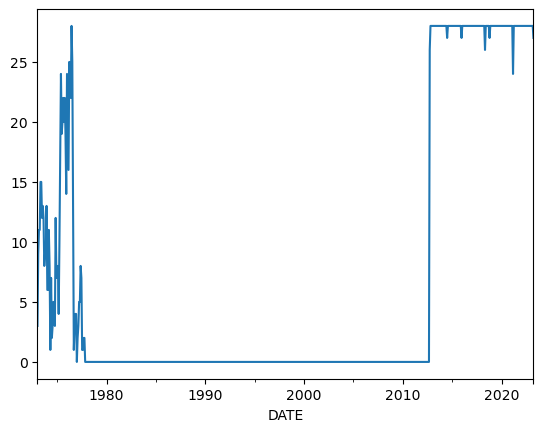

In [ ]:
count_stations('24338099999')

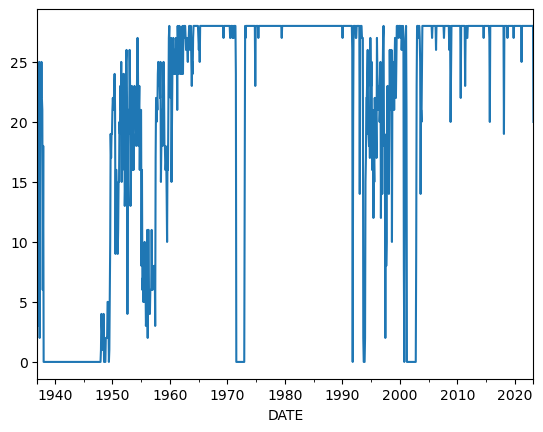

In [33]:
count_stations('20667099999')

In [20]:
dff.groupby([pd.Grouper(key='DATE', freq='4W')]).count()

,STATION,NAME,MXWDSP,WDSP,TEMP,STP,SLP,PRCP,DEWP,LATITUDE,LONGITUDE,ELEVATION
DATE,,,,,,,,,,,,
1948-01-04,2,2,2,2,2,0,2,1,0,2,2,2
1948-02-01,23,23,22,22,23,0,21,19,0,23,23,23
1948-02-29,15,15,14,15,15,0,15,14,0,15,15,15


In [ ]:
# Script to gather DATES of continuous stations
# def preprocess_grouped(grouped):
#     cont = 0
#     previous_was_okay = 0
#     list_of_dates = []
#     for (date, i) in zip(grouped.index, grouped.STATION):
#         if i >= 25:                  # try >=20 and ==28     Days in a 4-week period, should be 28
#             cont += 1
#             if cont >= 6:            # try >=3 and >=12      Continuous periods in a row
#                 end_date = date
#                 previous_was_okay = 1                      # Flag that says that previous 4-week period was continuous
        
#         else: 
#             cont = 0
#             if previous_was_okay:
#                 list_of_dates.append([start_date, end_date])
#                 previous_was_okay = 0
#             start_date = date
#     if previous_was_okay:
#         list_of_dates.append([start_date, end_date])    
#     return list_of_dates

### Download Stations

In [1]:
import requests
import os
import tarfile
for year in range(1929, 2024):
    os.mkdir('{}'.format(year) ) # create a directory
    URL = "https://www.ncei.noaa.gov/data/global-summary-of-the-day/archive/{}.tar.gz".format(year)
    response = requests.get(URL)
    open("{}.tar.gz".format(year), "wb").write(response.content) # save an archive
    
    file = tarfile.open('{}.tar.gz'.format(year)) # unarchive
    file.extractall('./{}'.format(year))
    file.close()